## 0. 최초 1회 라이브러리 설치

- `! pip install pyarrow` : **12-9. 특징 데이터 Parquet 파일 저장** 단계에서 필요
- 설치는 가상환경당 최초 1회만 하면 됨

## 1. 라이브러리 불러오기

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. 데이터 경로 설정

In [2]:
# UCI 유압 시스템 원본 데이터가 저장된 폴더 경로 설정
DATA_DIR = "../data/raw/uci_hydraulic/extracted"

# 설정한 데이터 폴더가 실제로 존재하는지 확인
print("데이터 폴더 존재 여부 :", os.path.exists(DATA_DIR))

데이터 폴더 존재 여부 : True


## 3. 원본 데이터 파일 확인

### 3-1. 데이터 폴더 내 파일 목록 확인

In [3]:
# 데이터 폴더 안에 어떤 파일들이 있는지 확인
file_list = os.listdir(DATA_DIR)

# 파일명을 보기 쉽게 정렬
file_list = sorted(file_list)

# 파일 목록 출력
print("파일 목록 :")
print(file_list)

파일 목록 :
['CE.txt', 'CP.txt', 'EPS1.txt', 'FS1.txt', 'FS2.txt', 'PS1.txt', 'PS2.txt', 'PS3.txt', 'PS4.txt', 'PS5.txt', 'PS6.txt', 'SE.txt', 'TS1.txt', 'TS2.txt', 'TS3.txt', 'TS4.txt', 'VS1.txt', 'description.txt', 'documentation.txt', 'profile.txt']


### 3-2. 센서 파일 17개 목록 정의

In [4]:
# 분석에 사용할 총 17개의 센서 파일명을 리스트로 정의
sensor_files = [
    "PS1.txt", "PS2.txt", "PS3.txt",
    "PS4.txt", "PS5.txt", "PS6.txt",
    "EPS1.txt",
    "FS1.txt", "FS2.txt",
    "TS1.txt", "TS2.txt", "TS3.txt", "TS4.txt",
    "VS1.txt",
    "CE.txt", "CP.txt", "SE.txt"
]

# 센서 파일 목록 출력
print("센서 파일 목록 :")
print(sensor_files)

센서 파일 목록 :
['PS1.txt', 'PS2.txt', 'PS3.txt', 'PS4.txt', 'PS5.txt', 'PS6.txt', 'EPS1.txt', 'FS1.txt', 'FS2.txt', 'TS1.txt', 'TS2.txt', 'TS3.txt', 'TS4.txt', 'VS1.txt', 'CE.txt', 'CP.txt', 'SE.txt']


### 3-3. 센서 파일 개수 확인

In [5]:
# 분석에 사용할 센서 파일이 총 17개인지 확인
print("센서 파일 개수 :", len(sensor_files))

센서 파일 개수 : 17


### 3-4. profile.txt 존재 여부 확인

In [6]:
# 정답 라벨이 저장된 profile.txt 파일의 전체 경로 생성
profile_path = os.path.join(DATA_DIR, "profile.txt")

# profile.txt 파일이 실제 데이터 폴더에 존재하는지 확인
print("profile.txt 존재 여부 :", os.path.exists(profile_path))

profile.txt 존재 여부 : True


## 4. 센서 데이터 사이클 수 검사

### 4-1. 센서 17개 데이터 불러오기

In [7]:
# 센서별 DataFrame을 저장할 딕셔너리 생성
# key   : 센서 파일명
# value : 해당 센서의 데이터
sensor_data = {}

# 3-2에서 정의한 sensor_files의 파일을 하나씩 불러오기
for file_name in sensor_files:

    # 데이터 폴더 경로와 파일명을 결합하여 전체 파일 경로 생성
    file_path = os.path.join(DATA_DIR, file_name)

    # 센서 데이터는 공백으로 값이 구분되어 있으며
    # 컬럼명이 존재하지 않으므로 header=None으로 불러옴
    sensor_data[file_name] = pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None
    )

# 정상적으로 17개의 센서가 불러와졌는지 확인
print("불러온 센서 파일 개수 :", len(sensor_data))

불러온 센서 파일 개수 : 17


### 4-2. 센서별 사이클 수 확인

In [8]:
# UCI 유압 시스템 데이터의 전체 운전 사이클 수
EXPECTED_CYCLES = 2205

# 센서별 사이클 수를 저장할 리스트
cycle_results = []

# 불러온 17개 센서의 사이클 수 확인
for file_name, df in sensor_data.items():

    # DataFrame의 행 개수는 운전 사이클의 개수를 의미
    cycle_count = df.shape[0]

    # 사이클 수가 기준인 2,205개와 같은지 확인
    if cycle_count == EXPECTED_CYCLES:
        status = "정상"
    else:
        status = "확인 필요"

    # 확인 결과 저장
    cycle_results.append({
        "센서 파일": file_name,
        "사이클 수": cycle_count,
        "검사 결과": status
    })

# 결과를 DataFrame으로 변환
cycle_check_df = pd.DataFrame(cycle_results)

# 센서별 사이클 수 출력
display(cycle_check_df)

,센서 파일,사이클 수,검사 결과
0,PS1.txt,2205,정상
1,PS2.txt,2205,정상
2,PS3.txt,2205,정상
3,PS4.txt,2205,정상
4,PS5.txt,2205,정상
5,PS6.txt,2205,정상
6,EPS1.txt,2205,정상
7,FS1.txt,2205,정상
8,FS2.txt,2205,정상
9,TS1.txt,2205,정상


### 4-3. 센서별 사이클당 데이터 수 확인

In [9]:
# 센서별 한 사이클당 측정값 개수를 저장할 리스트
sample_results = []

# 각 센서 DataFrame의 열 개수 확인
for file_name, df in sensor_data.items():

    # 열 개수는 하나의 60초 운전 사이클 동안
    # 해당 센서가 측정한 데이터 개수를 의미
    values_per_cycle = df.shape[1]

    # 결과 저장
    sample_results.append({
        "센서 파일": file_name,
        "사이클당 데이터 수": values_per_cycle
    })

# 결과를 DataFrame으로 변환
sample_check_df = pd.DataFrame(sample_results)

# 센서별 측정 데이터 개수 확인
display(sample_check_df)

,센서 파일,사이클당 데이터 수
0,PS1.txt,6000
1,PS2.txt,6000
2,PS3.txt,6000
3,PS4.txt,6000
4,PS5.txt,6000
5,PS6.txt,6000
6,EPS1.txt,6000
7,FS1.txt,600
8,FS2.txt,600
9,TS1.txt,60


### 4-4. profile.txt 사이클 수 확인

In [10]:
# 3-4에서 생성한 profile_path를 이용하여
# 정답 라벨 파일인 profile.txt 불러오기
profile_df = pd.read_csv(
    profile_path,
    sep=r"\s+",
    header=None
)

# profile.txt의 행 개수
# → 전체 운전 사이클 수
profile_cycle_count = profile_df.shape[0]

# profile.txt의 열 개수
# → 정답 라벨의 개수
profile_label_count = profile_df.shape[1]

print("profile.txt 사이클 수 :", profile_cycle_count)
print("profile.txt 라벨 수   :", profile_label_count)

profile.txt 사이클 수 : 2205
profile.txt 라벨 수   : 5


### 4-5. 전체 사이클 검사 결과 확인

In [11]:
# 17개 센서 파일의 사이클 수가
# 모두 2,205개인지 확인
all_sensor_normal = (
    cycle_check_df["사이클 수"] == EXPECTED_CYCLES
).all()

# profile.txt 역시 2,205개인지 확인
profile_normal = (
    profile_cycle_count == EXPECTED_CYCLES
)

# 센서 파일과 profile.txt가 모두 정상인지 최종 확인
if all_sensor_normal and profile_normal:
    print("검사 완료 : 센서 17개 파일과 profile.txt 모두 2,205개 사이클입니다.")
else:
    print("확인 필요 : 사이클 수가 다른 파일이 존재합니다.")

검사 완료 : 센서 17개 파일과 profile.txt 모두 2,205개 사이클입니다.


## 5. 센서 정보 정의

### 5-1. 센서명 정의

In [12]:
sensor_names = [
    file_name.replace(".txt", "")
    for file_name in sensor_files
]

print("센서명 목록 :")
print(sensor_names)

센서명 목록 :
['PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'EPS1', 'FS1', 'FS2', 'TS1', 'TS2', 'TS3', 'TS4', 'VS1', 'CE', 'CP', 'SE']


### 5-2. 센서별 물리량 정의

In [13]:
# 각 센서가 측정하는 물리량을 정의
#
# PS  : 압력
# EPS : 모터 전력
# FS  : 유량
# TS  : 온도
# VS  : 진동
# CE  : 냉각 효율
# CP  : 냉각 출력
# SE  : 효율 계수

sensor_types = {
    "PS1": "압력",
    "PS2": "압력",
    "PS3": "압력",
    "PS4": "압력",
    "PS5": "압력",
    "PS6": "압력",

    "EPS1": "모터 전력",

    "FS1": "유량",
    "FS2": "유량",

    "TS1": "온도",
    "TS2": "온도",
    "TS3": "온도",
    "TS4": "온도",

    "VS1": "진동",

    "CE": "냉각 효율",
    "CP": "냉각 출력",
    "SE": "효율 계수"
}

# 센서별 물리량 출력
print("센서별 물리량 :")
print(sensor_types)

센서별 물리량 :
{'PS1': '압력', 'PS2': '압력', 'PS3': '압력', 'PS4': '압력', 'PS5': '압력', 'PS6': '압력', 'EPS1': '모터 전력', 'FS1': '유량', 'FS2': '유량', 'TS1': '온도', 'TS2': '온도', 'TS3': '온도', 'TS4': '온도', 'VS1': '진동', 'CE': '냉각 효율', 'CP': '냉각 출력', 'SE': '효율 계수'}


### 5-3. 원본 문서에서 센서 단위 확인

In [14]:
# UCI 데이터와 함께 제공된 documentation.txt 경로 생성
documentation_path = os.path.join(DATA_DIR, "documentation.txt")

# 원본 문서의 문자 인코딩에 맞춰 cp1252로 파일 읽기
# 특수문자와 유럽권 문자가 깨지는 현상을 방지
with open(
    documentation_path,
    "r",
    encoding="cp1252"
) as file:
    documentation_text = file.read()

# 원본 문서 내용 출력
print("documentation.txt 내용 :")
print(documentation_text)

documentation.txt 내용 :
1. Title: Condition monitoring of hydraulic systems

2. Source Information
   -- Creator: Nikolai Helwig, ZeMA gGmbH, Eschberger Weg 46, 66121 Saarbrücken
   -- Donors (with approval from creator): M. Bastuck (m.bastuck@lmt.uni-saarland.de), T. Schneider (t.schneider@zema.de)
   -- Date: April, 2018
 
3. Past Usage:
   [1] Nikolai Helwig, Eliseo Pignanelli, Andreas Schütze, ‘Condition Monitoring of a Complex Hydraulic System Using Multivariate Statistics’, in Proc. I2MTC-2015 - 2015 IEEE International Instrumentation and Measurement Technology Conference, paper PPS1-39, Pisa, Italy, May 11-14, 2015. doi: 10.1109/I2MTC.2015.7151267
      -- detailed description of data and measurement setup
      -- automated feature extraction via Pearson correlation and comparison of several classification algorithms
      -- Cooler and Valve states are "easy" targets (perfect classification achieved), Pump and especially Accumulator states are more complex targets

   [2] N. He

### 5-4. 센서별 단위 정의

In [15]:
# documentation.txt에는 각 센서의 측정 단위가 명시되어 있지 않음
# 따라서 추정값을 사용하지 않고 "문서 미기재"로 기록
sensor_units = {
    "PS1": "문서 미기재",
    "PS2": "문서 미기재",
    "PS3": "문서 미기재",
    "PS4": "문서 미기재",
    "PS5": "문서 미기재",
    "PS6": "문서 미기재",

    "EPS1": "문서 미기재",

    "FS1": "문서 미기재",
    "FS2": "문서 미기재",

    "TS1": "문서 미기재",
    "TS2": "문서 미기재",
    "TS3": "문서 미기재",
    "TS4": "문서 미기재",

    "VS1": "문서 미기재",

    "CE": "문서 미기재",
    "CP": "문서 미기재",
    "SE": "문서 미기재"
}

# 센서별 단위 출력
print("센서별 단위 :")
print(sensor_units)

센서별 단위 :
{'PS1': '문서 미기재', 'PS2': '문서 미기재', 'PS3': '문서 미기재', 'PS4': '문서 미기재', 'PS5': '문서 미기재', 'PS6': '문서 미기재', 'EPS1': '문서 미기재', 'FS1': '문서 미기재', 'FS2': '문서 미기재', 'TS1': '문서 미기재', 'TS2': '문서 미기재', 'TS3': '문서 미기재', 'TS4': '문서 미기재', 'VS1': '문서 미기재', 'CE': '문서 미기재', 'CP': '문서 미기재', 'SE': '문서 미기재'}


### 5-5. 센서별 샘플링 속도 정의

In [16]:
# documentation.txt에 명시된 센서별 샘플링 속도 정의
#
# PS1 ~ PS6 : 100 Hz
# EPS1      : 100 Hz
# FS1 ~ FS2 : 10 Hz
# TS1 ~ TS4 : 1 Hz
# VS1       : 1 Hz
# CE        : 1 Hz
# CP        : 1 Hz
# SE        : 1 Hz

sensor_sampling_rates = {
    "PS1": 100,
    "PS2": 100,
    "PS3": 100,
    "PS4": 100,
    "PS5": 100,
    "PS6": 100,

    "EPS1": 100,

    "FS1": 10,
    "FS2": 10,

    "TS1": 1,
    "TS2": 1,
    "TS3": 1,
    "TS4": 1,

    "VS1": 1,

    "CE": 1,
    "CP": 1,
    "SE": 1
}

# 센서별 샘플링 속도 출력
print("센서별 샘플링 속도(Hz) :")
print(sensor_sampling_rates)

센서별 샘플링 속도(Hz) :
{'PS1': 100, 'PS2': 100, 'PS3': 100, 'PS4': 100, 'PS5': 100, 'PS6': 100, 'EPS1': 100, 'FS1': 10, 'FS2': 10, 'TS1': 1, 'TS2': 1, 'TS3': 1, 'TS4': 1, 'VS1': 1, 'CE': 1, 'CP': 1, 'SE': 1}


### 5-6. 센서별 사이클당 측정값 수 정의

In [17]:
# 한 운전 사이클은 60초
#
# 100 Hz × 60초 = 6,000개
# 10 Hz  × 60초 =   600개
# 1 Hz   × 60초 =    60개

sensor_values_per_cycle = {
    "PS1": 6000,
    "PS2": 6000,
    "PS3": 6000,
    "PS4": 6000,
    "PS5": 6000,
    "PS6": 6000,

    "EPS1": 6000,

    "FS1": 600,
    "FS2": 600,

    "TS1": 60,
    "TS2": 60,
    "TS3": 60,
    "TS4": 60,

    "VS1": 60,

    "CE": 60,
    "CP": 60,
    "SE": 60
}

# 센서별 사이클당 측정값 수 출력
print("센서별 사이클당 측정값 수 :")
print(sensor_values_per_cycle)

센서별 사이클당 측정값 수 :
{'PS1': 6000, 'PS2': 6000, 'PS3': 6000, 'PS4': 6000, 'PS5': 6000, 'PS6': 6000, 'EPS1': 6000, 'FS1': 600, 'FS2': 600, 'TS1': 60, 'TS2': 60, 'TS3': 60, 'TS4': 60, 'VS1': 60, 'CE': 60, 'CP': 60, 'SE': 60}


### 5-7. 센서 정보표 생성

In [18]:
# 지금까지 정의한 센서 정보를 하나의 표로 정리
#
# 컬럼 구성
# - 센서명
# - 물리량
# - 단위
# - 샘플링 속도(Hz)
# - 사이클당 측정값 수

sensor_info_df = pd.DataFrame({
    "센서명": sensor_names,
    "물리량": [sensor_types[sensor] for sensor in sensor_names],
    "단위": [sensor_units[sensor] for sensor in sensor_names],
    "샘플링 속도(Hz)": [
        sensor_sampling_rates[sensor]
        for sensor in sensor_names
    ],
    "사이클당 측정값 수": [
        sensor_values_per_cycle[sensor]
        for sensor in sensor_names
    ]
})

# 센서 정보표 출력
print("센서 정보표 :")
display(sensor_info_df)

센서 정보표 :


,센서명,물리량,단위,샘플링 속도(Hz),사이클당 측정값 수
0,PS1,압력,문서 미기재,100,6000
1,PS2,압력,문서 미기재,100,6000
2,PS3,압력,문서 미기재,100,6000
3,PS4,압력,문서 미기재,100,6000
4,PS5,압력,문서 미기재,100,6000
5,PS6,압력,문서 미기재,100,6000
6,EPS1,모터 전력,문서 미기재,100,6000
7,FS1,유량,문서 미기재,10,600
8,FS2,유량,문서 미기재,10,600
9,TS1,온도,문서 미기재,1,60


## 6. profile.txt 라벨 구조 확인

### 6-1. profile.txt 데이터 크기 확인

In [19]:
# 4-4에서 불러온 profile_df 사용
profile_df = pd.read_csv(
    profile_path,
    sep=r"\s+",
    header=None
)

# profile.txt 데이터 크기 출력
print("profile.txt 데이터 크기 :")
print(profile_df.shape)

profile.txt 데이터 크기 :
(2205, 5)


### 6-2. profile.txt 라벨 컬럼명 지정

In [20]:
# documentation.txt에 기록된 순서에 따라
# profile.txt의 5개 라벨 컬럼에 이름을 지정
#
# cooler      : 냉각기 상태
# valve       : 밸브 상태
# pump        : 펌프 내부 누설 상태
# accumulator : 축압기 상태
# stable_flag : 측정 조건 안정 상태

profile_df.columns = [
    "cooler",
    "valve",
    "pump",
    "accumulator",
    "stable_flag"
]

# 지정된 컬럼명 출력
print("profile.txt 라벨 컬럼 :")
print(profile_df.columns.tolist())

profile.txt 라벨 컬럼 :
['cooler', 'valve', 'pump', 'accumulator', 'stable_flag']


### 6-3. profile.txt 라벨 데이터 일부 확인

In [21]:
# profile.txt의 앞 5개 데이터를 확인하여
# 각 라벨 컬럼에 값이 정상적으로 들어왔는지 확인

print("profile.txt 라벨 데이터 :")
display(profile_df.head())

profile.txt 라벨 데이터 :


,cooler,valve,pump,accumulator,stable_flag
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1
3,3,100,0,130,1
4,3,100,0,130,1


### 6-4. profile.txt 라벨 결측값 확인

In [22]:
# 각 라벨 컬럼에 결측값이 존재하는지 확인
# isnull()  : 값이 비어 있는지 검사
# sum()     : 컬럼별 결측값 개수 계산

missing_values = profile_df.isnull().sum()

# 라벨별 결측값 개수 출력
print("라벨별 결측값 개수 :")
print(missing_values)

라벨별 결측값 개수 :
cooler         0
valve          0
pump           0
accumulator    0
stable_flag    0
dtype: int64


## 7. 라벨별 상태 코드 및 의미 정의

### 7-1. 냉각기 상태 코드 및 의미 정의

In [23]:
# documentation.txt의 Cooler condition 기준
#
# 3   : 거의 완전 고장 상태
# 20  : 효율 저하 상태
# 100 : 정상 효율 상태

cooler_labels = {
    3: "고장 근접",
    20: "효율 저하",
    100: "정상"
}

# 실제 profile.txt에 존재하는 냉각기 상태 코드 확인
print("냉각기 실제 상태 코드 :")
print(sorted(profile_df["cooler"].unique()))

# 상태 코드별 의미 출력
print("냉각기 상태 의미 :")
print(cooler_labels)

냉각기 실제 상태 코드 :
[np.int64(3), np.int64(20), np.int64(100)]
냉각기 상태 의미 :
{3: '고장 근접', 20: '효율 저하', 100: '정상'}


### 7-2. 밸브 상태 코드 및 의미 정의

In [24]:
# documentation.txt의 Valve condition 기준
#
# 73  : 거의 완전 고장 상태
# 80  : 심각한 동작 지연
# 90  : 약한 동작 지연
# 100 : 정상 동작 상태

valve_labels = {
    73: "고장 근접",
    80: "심각한 동작 지연",
    90: "약한 동작 지연",
    100: "정상"
}

# 실제 profile.txt에 존재하는 밸브 상태 코드 확인
print("밸브 실제 상태 코드 :")
print(sorted(profile_df["valve"].unique()))

# 상태 코드별 의미 출력
print("밸브 상태 의미 :")
print(valve_labels)

밸브 실제 상태 코드 :
[np.int64(73), np.int64(80), np.int64(90), np.int64(100)]
밸브 상태 의미 :
{73: '고장 근접', 80: '심각한 동작 지연', 90: '약한 동작 지연', 100: '정상'}


### 7-3. 펌프 상태 코드 및 의미 정의

In [25]:
# documentation.txt의 Internal pump leakage 기준
#
# 0 : 누설 없음
# 1 : 약한 누설
# 2 : 심각한 누설

pump_labels = {
    0: "누설 없음",
    1: "약한 누설",
    2: "심각한 누설"
}

# 실제 profile.txt에 존재하는 펌프 상태 코드 확인
print("펌프 실제 상태 코드 :")
print(sorted(profile_df["pump"].unique()))

# 상태 코드별 의미 출력
print("펌프 상태 의미 :")
print(pump_labels)

펌프 실제 상태 코드 :
[np.int64(0), np.int64(1), np.int64(2)]
펌프 상태 의미 :
{0: '누설 없음', 1: '약한 누설', 2: '심각한 누설'}


### 7-4. 축압기 상태 코드 및 의미 정의

In [26]:
# documentation.txt의 Hydraulic accumulator 기준
#
# 90  : 거의 완전 고장 상태
# 100 : 압력이 심각하게 감소한 상태
# 115 : 압력이 약간 감소한 상태
# 130 : 정상 압력 상태

accumulator_labels = {
    90: "고장 근접",
    100: "압력 심각 저하",
    115: "압력 약간 저하",
    130: "정상"
}

# 실제 profile.txt에 존재하는 축압기 상태 코드 확인
print("축압기 실제 상태 코드 :")
print(sorted(profile_df["accumulator"].unique()))

# 상태 코드별 의미 출력
print("축압기 상태 의미 :")
print(accumulator_labels)

축압기 실제 상태 코드 :
[np.int64(90), np.int64(100), np.int64(115), np.int64(130)]
축압기 상태 의미 :
{90: '고장 근접', 100: '압력 심각 저하', 115: '압력 약간 저하', 130: '정상'}


### 7-5. 안정 상태 코드 및 의미 정의

In [27]:
# documentation.txt의 stable flag 기준
#
# 0 : 측정 조건이 안정된 상태
# 1 : 아직 안정 상태에 도달하지 않았을 가능성이 있는 상태

stable_labels = {
    0: "안정",
    1: "미안정 가능"
}

# 실제 profile.txt에 존재하는 안정 상태 코드 확인
print("안정 상태 실제 코드 :")
print(sorted(profile_df["stable_flag"].unique()))

# 상태 코드별 의미 출력
print("안정 상태 의미 :")
print(stable_labels)

안정 상태 실제 코드 :
[np.int64(0), np.int64(1)]
안정 상태 의미 :
{0: '안정', 1: '미안정 가능'}


## 8. 라벨 클래스 분포 확인

### 8-1. 냉각기 클래스 분포 확인

In [28]:
# 냉각기 상태 코드별 데이터 개수 계산
cooler_counts = (
    profile_df["cooler"]
    .value_counts()
    .sort_index()
)

# 상태 코드별 의미와 데이터 개수를 표로 정리
cooler_distribution = pd.DataFrame({
    "상태 코드": cooler_counts.index,
    "상태": [
        cooler_labels[code]
        for code in cooler_counts.index
    ],
    "데이터 개수": cooler_counts.values
})

# 전체 데이터에서 각 상태가 차지하는 비율 계산
cooler_distribution["비율(%)"] = (
    cooler_distribution["데이터 개수"]
    / len(profile_df)
    * 100
).round(2)

# 냉각기 클래스 분포 출력
print("냉각기 클래스 분포 :")
display(cooler_distribution)

냉각기 클래스 분포 :


,상태 코드,상태,데이터 개수,비율(%)
0,3,고장 근접,732,33.20
1,20,효율 저하,732,33.20
2,100,정상,741,33.61


### 8-2. 밸브 클래스 분포 확인

In [29]:
# 밸브 상태 코드별 데이터 개수 계산
valve_counts = (
    profile_df["valve"]
    .value_counts()
    .sort_index()
)

# 상태 코드별 의미와 데이터 개수를 표로 정리
valve_distribution = pd.DataFrame({
    "상태 코드": valve_counts.index,
    "상태": [
        valve_labels[code]
        for code in valve_counts.index
    ],
    "데이터 개수": valve_counts.values
})

# 전체 데이터에서 각 상태가 차지하는 비율 계산
valve_distribution["비율(%)"] = (
    valve_distribution["데이터 개수"]
    / len(profile_df)
    * 100
).round(2)

# 밸브 클래스 분포 출력
print("밸브 클래스 분포 :")
display(valve_distribution)

밸브 클래스 분포 :


,상태 코드,상태,데이터 개수,비율(%)
0,73,고장 근접,360,16.33
1,80,심각한 동작 지연,360,16.33
2,90,약한 동작 지연,360,16.33
3,100,정상,1125,51.02


### 8-3. 펌프 클래스 분포 확인

In [30]:
# 펌프 상태 코드별 데이터 개수 계산
pump_counts = (
    profile_df["pump"]
    .value_counts()
    .sort_index()
)

# 상태 코드별 의미와 데이터 개수를 표로 정리
pump_distribution = pd.DataFrame({
    "상태 코드": pump_counts.index,
    "상태": [
        pump_labels[code]
        for code in pump_counts.index
    ],
    "데이터 개수": pump_counts.values
})

# 전체 데이터에서 각 상태가 차지하는 비율 계산
pump_distribution["비율(%)"] = (
    pump_distribution["데이터 개수"]
    / len(profile_df)
    * 100
).round(2)

# 펌프 클래스 분포 출력
print("펌프 클래스 분포 :")
display(pump_distribution)

펌프 클래스 분포 :


,상태 코드,상태,데이터 개수,비율(%)
0,0,누설 없음,1221,55.37
1,1,약한 누설,492,22.31
2,2,심각한 누설,492,22.31


### 8-4. 축압기 클래스 분포 확인

In [31]:
# 축압기 상태 코드별 데이터 개수 계산
accumulator_counts = (
    profile_df["accumulator"]
    .value_counts()
    .sort_index()
)

# 상태 코드별 의미와 데이터 개수를 표로 정리
accumulator_distribution = pd.DataFrame({
    "상태 코드": accumulator_counts.index,
    "상태": [
        accumulator_labels[code]
        for code in accumulator_counts.index
    ],
    "데이터 개수": accumulator_counts.values
})

# 전체 데이터에서 각 상태가 차지하는 비율 계산
accumulator_distribution["비율(%)"] = (
    accumulator_distribution["데이터 개수"]
    / len(profile_df)
    * 100
).round(2)

# 축압기 클래스 분포 출력
print("축압기 클래스 분포 :")
display(accumulator_distribution)

축압기 클래스 분포 :


,상태 코드,상태,데이터 개수,비율(%)
0,90,고장 근접,808,36.64
1,100,압력 심각 저하,399,18.10
2,115,압력 약간 저하,399,18.10
3,130,정상,599,27.17


### 8-5. 안정 상태 클래스 분포 확인

In [32]:
# 안정 상태 코드별 데이터 개수 계산
stable_counts = (
    profile_df["stable_flag"]
    .value_counts()
    .sort_index()
)

# 상태 코드별 의미와 데이터 개수를 표로 정리
stable_distribution = pd.DataFrame({
    "상태 코드": stable_counts.index,
    "상태": [
        stable_labels[code]
        for code in stable_counts.index
    ],
    "데이터 개수": stable_counts.values
})

# 전체 데이터에서 각 상태가 차지하는 비율 계산
stable_distribution["비율(%)"] = (
    stable_distribution["데이터 개수"]
    / len(profile_df)
    * 100
).round(2)

# 안정 상태 클래스 분포 출력
print("안정 상태 클래스 분포 :")
display(stable_distribution)

안정 상태 클래스 분포 :


,상태 코드,상태,데이터 개수,비율(%)
0,0,안정,1449,65.71
1,1,미안정 가능,756,34.29


### 8-6. 전체 라벨 클래스 분포 요약

In [33]:
# 각 라벨별 클래스 개수와 전체 데이터 수를 정리
label_summary_df = pd.DataFrame({
    "라벨": [
        "냉각기",
        "밸브",
        "펌프",
        "축압기",
        "안정 상태"
    ],
    "클래스 수": [
        profile_df["cooler"].nunique(),
        profile_df["valve"].nunique(),
        profile_df["pump"].nunique(),
        profile_df["accumulator"].nunique(),
        profile_df["stable_flag"].nunique()
    ],
    "전체 데이터 수": [
        profile_df["cooler"].count(),
        profile_df["valve"].count(),
        profile_df["pump"].count(),
        profile_df["accumulator"].count(),
        profile_df["stable_flag"].count()
    ]
})

# 전체 라벨 분포 요약표 출력
print("전체 라벨 클래스 분포 요약 :")
display(label_summary_df)

전체 라벨 클래스 분포 요약 :


,라벨,클래스 수,전체 데이터 수
0,냉각기,3,2205
1,밸브,4,2205
2,펌프,3,2205
3,축압기,4,2205
4,안정 상태,2,2205


## 9. cycle_id 부여

### 9-1. profile.txt에 cycle_id 부여

In [34]:
# 전체 2,205개의 운전 사이클에 고유 번호 부여
# cycle_id는 1부터 시작하여 2205까지 생성

profile_df.insert(
    0,
    "cycle_id",
    range(1, len(profile_df) + 1)
)

# cycle_id가 정상적으로 추가되었는지 확인
print("profile 데이터 일부 :")
display(profile_df.head())

profile 데이터 일부 :


,cycle_id,cooler,valve,pump,accumulator,stable_flag
0,1,3,100,0,130,1
1,2,3,100,0,130,1
2,3,3,100,0,130,1
3,4,3,100,0,130,1
4,5,3,100,0,130,1


### 9-2. 센서 17개 데이터에 cycle_id 부여

In [35]:
# sensor_data 딕셔너리에 저장된
# 모든 센서 DataFrame에 cycle_id 컬럼 추가
for file_name, df in sensor_data.items():

    # 첫 번째 컬럼 위치(0)에 cycle_id 추가
    df.insert(
        0,
        "cycle_id",
        range(1, len(df) + 1)
    )

# 제대로 추가되었는지 PS1.txt로 확인
print("PS1.txt 데이터 일부 :")
display(sensor_data["PS1.txt"].head())

PS1.txt 데이터 일부 :


,cycle_id,0,1,2,3,4,5,6,7,8,...,5990,5991,5992,5993,5994,5995,5996,5997,5998,5999
0,1,151.47,151.45,151.52,151.27,150.80,150.69,153.89,154.67,152.88,...,151.16,151.19,151.25,151.16,151.10,151.16,151.14,151.10,151.21,151.19
1,2,151.11,151.12,151.16,150.92,150.70,150.62,152.40,153.21,152.81,...,150.82,150.82,150.86,150.80,150.73,150.79,150.84,150.79,150.80,150.86
2,3,150.81,150.79,150.84,150.65,150.35,150.23,152.03,152.81,152.44,...,150.49,150.44,150.47,150.46,150.38,150.47,150.50,150.43,150.54,150.62
3,4,150.48,150.47,150.52,150.31,150.04,149.98,151.63,152.48,152.24,...,150.34,150.30,150.28,150.38,150.41,150.33,150.31,150.31,150.25,150.28
4,5,150.41,150.35,150.24,150.12,149.87,149.71,151.64,152.37,151.78,...,150.31,150.20,150.17,150.28,150.31,150.25,150.27,150.22,150.13,150.19


### 9-3. 전체 데이터 cycle_id 일치 여부 확인

In [36]:
expected_cycle_id = list(range(1, 2206))

# profile.txt 확인
profile_ok = profile_df["cycle_id"].tolist() == expected_cycle_id
print("profile.txt :", profile_ok)

# 센서 17개 확인
for file_name, df in sensor_data.items():
    sensor_ok = df["cycle_id"].tolist() == expected_cycle_id
    print(file_name, ":", sensor_ok)

profile.txt : True
PS1.txt : True
PS2.txt : True
PS3.txt : True
PS4.txt : True
PS5.txt : True
PS6.txt : True
EPS1.txt : True
FS1.txt : True
FS2.txt : True
TS1.txt : True
TS2.txt : True
TS3.txt : True
TS4.txt : True
VS1.txt : True
CE.txt : True
CP.txt : True
SE.txt : True


## 10. Train / Validation / Test 분할

### 10-1. Train / Validation / Test cycle_id 분할

In [37]:
# 전체 cycle_id 가져오기
all_cycle_ids = profile_df["cycle_id"].tolist()

# 전체 사이클 개수
n_total = len(all_cycle_ids)

# 70% / 15% / 15% 기준 위치 계산
train_end = int(n_total * 0.70)
val_end = int(n_total * 0.85)

# 시간 순서대로 분할
train_ids = all_cycle_ids[:train_end]
val_ids = all_cycle_ids[train_end:val_end]
test_ids = all_cycle_ids[val_end:]

# 개수 확인
print("전체 :", n_total)
print("Train :", len(train_ids))
print("Validation :", len(val_ids))
print("Test :", len(test_ids))

전체 : 2205
Train : 1543
Validation : 331
Test : 331


### 10-2. Train / Validation / Test cycle_id 중복 검사

In [38]:
train_val_overlap = set(train_ids) & set(val_ids)
train_test_overlap = set(train_ids) & set(test_ids)
val_test_overlap = set(val_ids) & set(test_ids)

print("Train ↔ Validation 중복 :", len(train_val_overlap))
print("Train ↔ Test 중복 :", len(train_test_overlap))
print("Validation ↔ Test 중복 :", len(val_test_overlap))

Train ↔ Validation 중복 : 0
Train ↔ Test 중복 : 0
Validation ↔ Test 중복 : 0


### 10-3. Train / Validation / Test 범위 확인

In [39]:
print("Train 범위 :", train_ids[0], "~", train_ids[-1])
print("Validation 범위 :", val_ids[0], "~", val_ids[-1])
print("Test 범위 :", test_ids[0], "~", test_ids[-1])

Train 범위 : 1 ~ 1543
Validation 범위 : 1544 ~ 1874
Test 범위 : 1875 ~ 2205


## 11. EDA - 데이터 분포 및 대표 센서 비교

### 11-1. 부품별 상태 클래스 분포


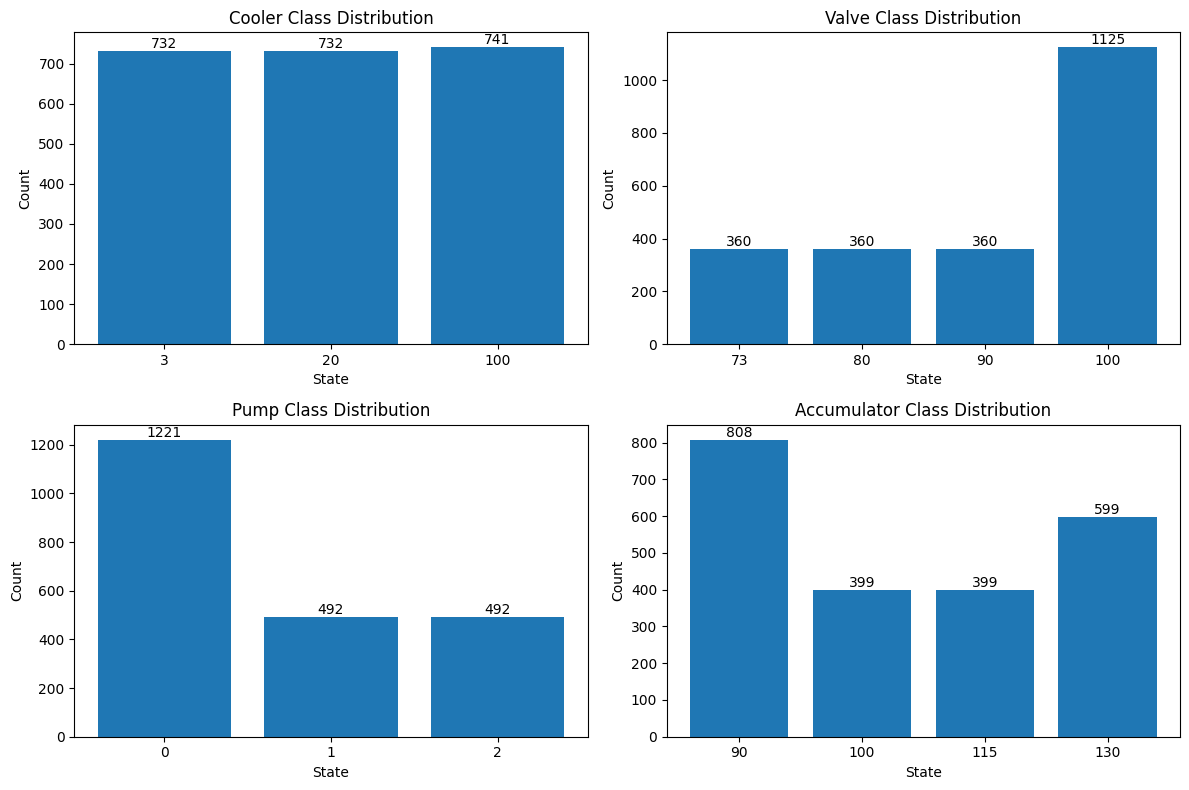

In [40]:
# EDA 그래프 저장 폴더
eda_dir = "../reports/eda"
os.makedirs(eda_dir, exist_ok=True)

# 예측 대상 4개 부품
components = ["cooler", "valve", "pump", "accumulator"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, component in zip(axes, components):

    # 상태 코드별 데이터 개수
    counts = (
        profile_df[component]
        .value_counts()
        .sort_index()
    )

    ax.bar(
        counts.index.astype(str),
        counts.values
    )

    ax.set_title(
        f"{component.capitalize()} Class Distribution"
    )
    ax.set_xlabel("State")
    ax.set_ylabel("Count")

    # 막대 위에 데이터 개수 표시
    for i, value in enumerate(counts.values):
        ax.text(
            i,
            value,
            str(value),
            ha="center",
            va="bottom"
        )

plt.tight_layout()

plt.savefig(
    os.path.join(
        eda_dir,
        "component_class_distribution.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


### 11-2. 펌프 정상 / 심각 누설 상태의 PS1 비교


In [41]:
# 펌프 상태
# 0 = 누설 없음(정상)
# 2 = 심각한 누설

normal_cycle_id = profile_df.loc[
    profile_df["pump"] == 0, "cycle_id"
].iloc[0]

severe_cycle_id = profile_df.loc[
    profile_df["pump"] == 2, "cycle_id"
].iloc[0]

print("정상 펌프 cycle_id :", normal_cycle_id)
print("심각 누설 cycle_id :", severe_cycle_id)

정상 펌프 cycle_id : 1
심각 누설 cycle_id : 211


### 11-3. 정상 / 심각 누설 PS1 신호 그래프 비교


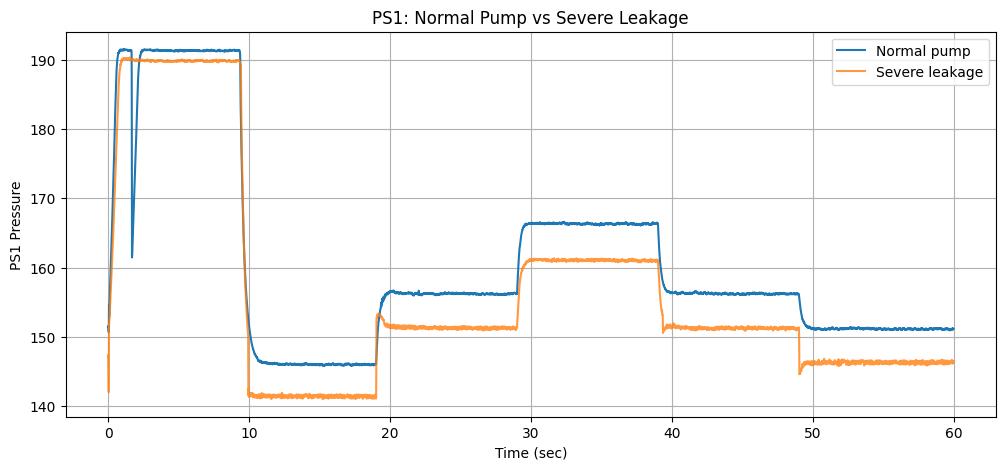

In [42]:
# cycle_id에 해당하는 PS1 데이터 가져오기
normal_ps1 = sensor_data["PS1.txt"].loc[
    sensor_data["PS1.txt"]["cycle_id"] == normal_cycle_id
].iloc[0, 1:].astype(float).values

severe_ps1 = sensor_data["PS1.txt"].loc[
    sensor_data["PS1.txt"]["cycle_id"] == severe_cycle_id
].iloc[0, 1:].astype(float).values

# PS1은 100Hz → 1초에 100개 측정
time = np.arange(len(normal_ps1)) / 100

# 그래프 그리기
plt.figure(figsize=(12, 5))

plt.plot(time, normal_ps1, label="Normal pump")
plt.plot(time, severe_ps1, label="Severe leakage", alpha=0.8)

plt.xlabel("Time (sec)")
plt.ylabel("PS1 Pressure")
plt.title("PS1: Normal Pump vs Severe Leakage")
plt.legend()
plt.grid(True)

plt.show()

### 11-4. 정상 / 심각 누설 PS1 통계 비교


In [43]:
print("[정상 펌프]")
print("평균 :", normal_ps1.mean())
print("표준편차 :", normal_ps1.std())
print("최솟값 :", normal_ps1.min())
print("최댓값 :", normal_ps1.max())

print()

print("[심각 누설]")
print("평균 :", severe_ps1.mean())
print("표준편차 :", severe_ps1.std())
print("최솟값 :", severe_ps1.min())
print("최댓값 :", severe_ps1.max())

[정상 펌프]
평균 : 160.67349166666665
표준편차 : 13.938146895896788
최솟값 : 145.83
최댓값 : 191.51

[심각 누설]
평균 : 156.39146166666666
표준편차 : 15.160827425095588
최솟값 : 141.02
최댓값 : 190.31


## 12. 시계열 특징 추출

### 12-1. PS1 한 사이클의 통계 특징 추출

In [44]:
# 정상 펌프 cycle_id = 1의 PS1 데이터 사용
values = normal_ps1

mean_value = np.mean(values)
std_value = np.std(values)
min_value = np.min(values)
max_value = np.max(values)

# 범위 = 최댓값 - 최솟값
range_value = max_value - min_value

# RMS
rms_value = np.sqrt(np.mean(values ** 2))

print("평균 :", mean_value)
print("표준편차 :", std_value)
print("최솟값 :", min_value)
print("최댓값 :", max_value)
print("범위 :", range_value)
print("RMS :", rms_value)

평균 : 160.67349166666665
표준편차 : 13.938146895896788
최솟값 : 145.83
최댓값 : 191.51
범위 : 45.67999999999998
RMS : 161.27691360901596


### 12-2. 기울기(slope) 특징 계산

In [45]:
# x축: 측정 순서
x = np.arange(len(values))

# 1차 직선으로 근사해서 기울기 계산
slope_value = np.polyfit(x, values, 1)[0]

print("기울기 :", slope_value)

기울기 : -0.004043084019252369


### 12-3. 특징 추출 함수 만들기

In [46]:
def extract_features(values, sample_rate):
    
    # 숫자 배열로 변환
    values = np.asarray(values, dtype=float)

    # 시간축 생성 (초 단위)
    time = np.arange(len(values)) / sample_rate

    # 7개 특징 계산
    mean_value = np.mean(values)
    std_value = np.std(values)
    min_value = np.min(values)
    max_value = np.max(values)
    range_value = max_value - min_value
    slope_value = np.polyfit(time, values, 1)[0]
    rms_value = np.sqrt(np.mean(values ** 2))

    return {
        "mean": mean_value,
        "std": std_value,
        "min": min_value,
        "max": max_value,
        "range": range_value,
        "slope": slope_value,
        "rms": rms_value
    }

In [47]:
# PS1은 100Hz
ps1_features = extract_features(
    normal_ps1,
    sample_rate=100
)

print(ps1_features)

{'mean': np.float64(160.67349166666665), 'std': np.float64(13.938146895896788), 'min': np.float64(145.83), 'max': np.float64(191.51), 'range': np.float64(45.67999999999998), 'slope': np.float64(-0.40430840192523587), 'rms': np.float64(161.27691360901596)}


### 12-4. 특징 추출용 센서 샘플링 속도 설정

In [48]:
# 5-5에서 정의한 샘플링 속도를 파일명 기준으로 변환
sample_rates = {
    f"{sensor_name}.txt": sample_rate
    for sensor_name, sample_rate in sensor_sampling_rates.items()
}

print("등록된 센서 수 :", len(sample_rates))

등록된 센서 수 : 17


### 12-5. 입력 시간별 특징 데이터 생성 함수

In [49]:
def make_feature_table(window_sec):

    feature_dict = {
        "cycle_id": profile_df["cycle_id"].values
    }

    # 센서 17개 반복
    for file_name, sample_rate in sample_rates.items():

        sensor_name = file_name.replace(".txt", "")

        # 사용할 데이터 개수
        # 예: PS1 100Hz × 10초 = 1000개
        n_samples = sample_rate * window_sec

        # cycle_id 제외 + 처음 window_sec만 사용
        values = sensor_data[file_name].iloc[
            :, 1:n_samples + 1
        ].to_numpy(dtype=float)

        # 초 단위 시간축
        time = np.arange(values.shape[1]) / sample_rate

        # 7개 특징
        mean_values = np.mean(values, axis=1)
        std_values = np.std(values, axis=1)
        min_values = np.min(values, axis=1)
        max_values = np.max(values, axis=1)
        range_values = max_values - min_values
        slope_values = np.polyfit(time, values.T, 1)[0]
        rms_values = np.sqrt(np.mean(values ** 2, axis=1))

        feature_dict[f"{sensor_name}_mean"] = mean_values
        feature_dict[f"{sensor_name}_std"] = std_values
        feature_dict[f"{sensor_name}_min"] = min_values
        feature_dict[f"{sensor_name}_max"] = max_values
        feature_dict[f"{sensor_name}_range"] = range_values
        feature_dict[f"{sensor_name}_slope"] = slope_values
        feature_dict[f"{sensor_name}_rms"] = rms_values

    return pd.DataFrame(feature_dict)

### 12-6. 10 / 20 / 30 / 60초 특징 생성

In [50]:
features_10s = make_feature_table(10)
features_20s = make_feature_table(20)
features_30s = make_feature_table(30)
features_60s = make_feature_table(60)

print("10초 :", features_10s.shape)
print("20초 :", features_20s.shape)
print("30초 :", features_30s.shape)
print("60초 :", features_60s.shape)

10초 : (2205, 120)
20초 : (2205, 120)
30초 : (2205, 120)
60초 : (2205, 120)


### 12-7. 특징 데이터 컬럼 순서 일치 확인

In [51]:
same_10_20 = list(features_10s.columns) == list(features_20s.columns)
same_10_30 = list(features_10s.columns) == list(features_30s.columns)
same_10_60 = list(features_10s.columns) == list(features_60s.columns)

print("10초 ↔ 20초 :", same_10_20)
print("10초 ↔ 30초 :", same_10_30)
print("10초 ↔ 60초 :", same_10_60)

10초 ↔ 20초 : True
10초 ↔ 30초 : True
10초 ↔ 60초 : True


### 12-8. 10 / 20 / 30 / 60초 특징 데이터 이상값 검사

In [52]:
feature_tables = {
    "10초": features_10s,
    "20초": features_20s,
    "30초": features_30s,
    "60초": features_60s
}

for name, df in feature_tables.items():

    # 결측값 개수
    nan_count = df.isna().sum().sum()

    # cycle_id 제외 후 무한값 검사
    numeric_data = df.drop(columns=["cycle_id"])
    inf_count = np.isinf(
        numeric_data.to_numpy()
    ).sum()

    print(
        name,
        "| NaN :", nan_count,
        "| inf :", inf_count
    )

10초 | NaN : 0 | inf : 0
20초 | NaN : 0 | inf : 0
30초 | NaN : 0 | inf : 0
60초 | NaN : 0 | inf : 0


### 12-9. 특징 데이터 Parquet 파일로 저장

In [53]:
# 저장 폴더
processed_path = "../data/processed"

# 폴더가 없으면 생성
os.makedirs(processed_path, exist_ok=True)

# Parquet 저장
features_10s.to_parquet(
    os.path.join(processed_path, "features_10s.parquet"),
    index=False
)

features_20s.to_parquet(
    os.path.join(processed_path, "features_20s.parquet"),
    index=False
)

features_30s.to_parquet(
    os.path.join(processed_path, "features_30s.parquet"),
    index=False
)

features_60s.to_parquet(
    os.path.join(processed_path, "features_60s.parquet"),
    index=False
)

print("특징 파일 저장 완료")

특징 파일 저장 완료


### 12-10. 저장된 특징 파일 확인

In [54]:
for file_name in [
    "features_10s.parquet",
    "features_20s.parquet",
    "features_30s.parquet",
    "features_60s.parquet"
]:
    file_path = os.path.join(processed_path, file_name)

    print(
        file_name,
        ":",
        os.path.exists(file_path)
    )

features_10s.parquet : True
features_20s.parquet : True
features_30s.parquet : True
features_60s.parquet : True


### 12-11. EDA - 대표 센서 특징 분포

- PS1(압력), FS1(유량), TS1(온도), VS1(진동)의 60초 평균 특징 분포를 확인한다.
- 센서값이 특정 한 구간에만 몰리는지, 여러 구간에 나뉘는지 확인한다.
- 서로 다른 물리량의 분포 차이를 확인하여 이후 다중 센서 특징을 함께 사용하는 근거로 활용한다.


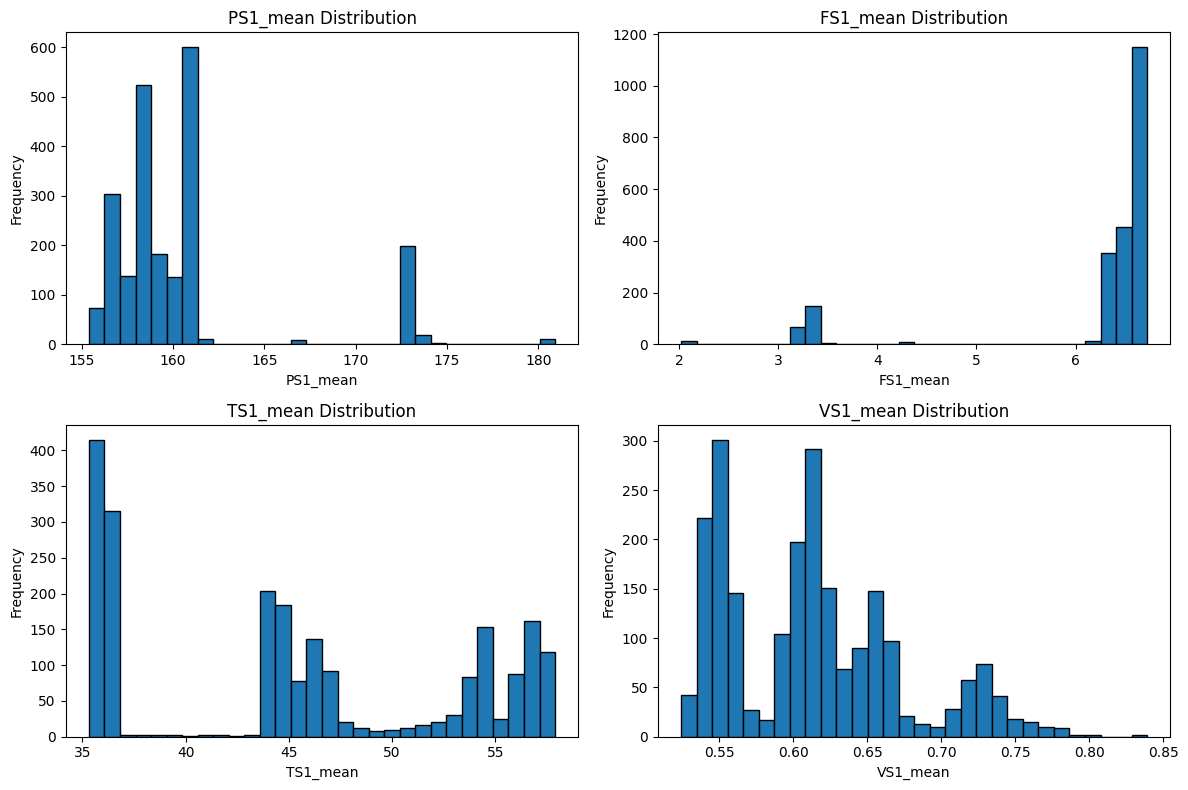

In [55]:
# 대표 센서의 평균 특징
sensor_features = [
    "PS1_mean",
    "FS1_mean",
    "TS1_mean",
    "VS1_mean"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature in zip(axes, sensor_features):

    ax.hist(
        features_60s[feature],
        bins=30,
        edgecolor="black"
    )

    ax.set_title(
        f"{feature} Distribution"
    )
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    os.path.join(
        eda_dir,
        "representative_sensor_distribution.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


### 12-12. EDA - 부품 상태별 대표 센서 변화

부품 상태에 따라 대표 센서 특징의 분포가 어떻게 달라지는지 비교한다.

- Cooler: `CE_mean`
- Valve: `FS1_mean`
- Pump: `EPS1_mean`
- Accumulator: `PS1_mean`

각 부품은 하나의 센서만으로 상태를 완전히 구분하기보다 여러 센서 특징을 함께 사용해야 하는지 확인한다.


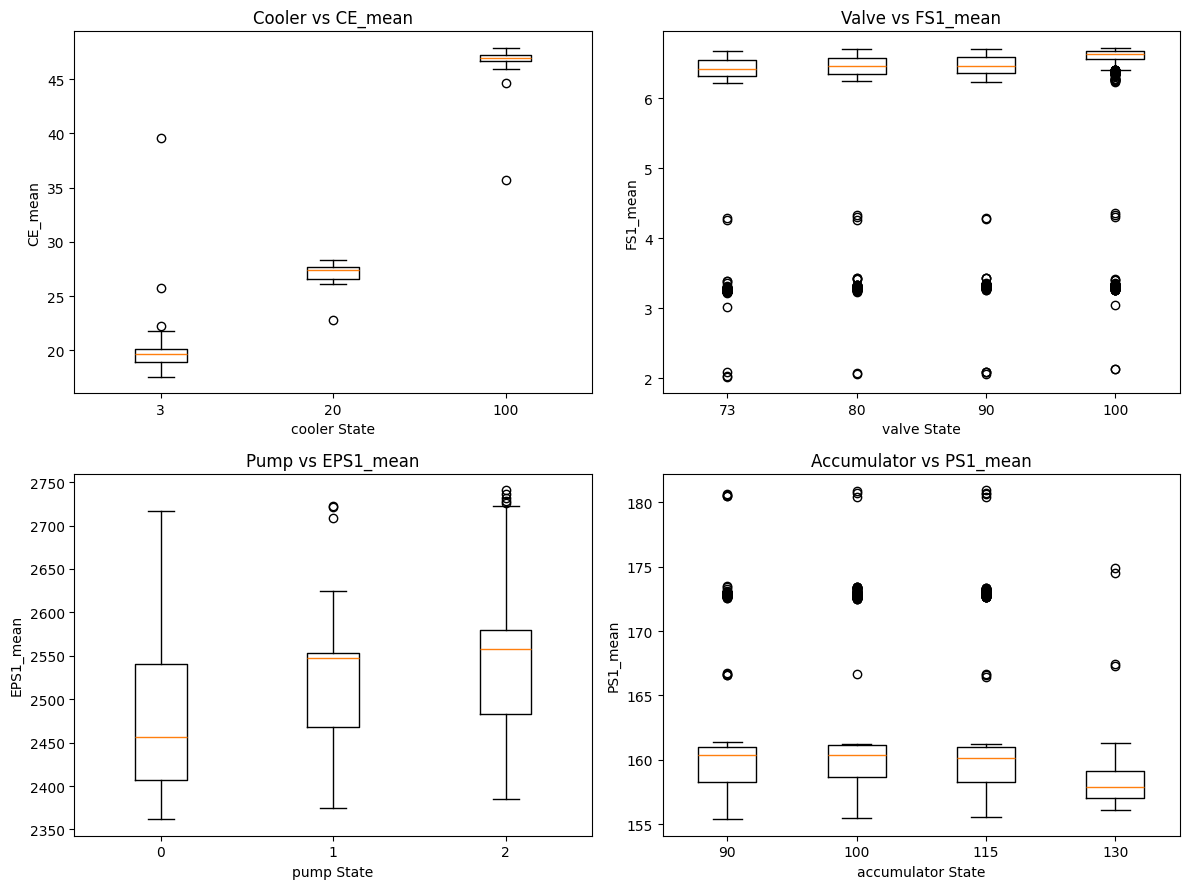

In [56]:
# 60초 특징 데이터와 정답 라벨 결합
eda_df = features_60s.merge(
    profile_df[
        [
            "cycle_id",
            "cooler",
            "valve",
            "pump",
            "accumulator"
        ]
    ],
    on="cycle_id",
    how="inner"
)

# 부품별 대표 센서 특징
component_features = {
    "cooler": "CE_mean",
    "valve": "FS1_mean",
    "pump": "EPS1_mean",
    "accumulator": "PS1_mean"
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (component, feature) in zip(
    axes,
    component_features.items()
):

    states = sorted(
        eda_df[component].unique()
    )

    box_data = [
        eda_df.loc[
            eda_df[component] == state,
            feature
        ]
        for state in states
    ]

    ax.boxplot(
        box_data,
        tick_labels=[
            str(state)
            for state in states
        ]
    )

    ax.set_title(
        f"{component.capitalize()} vs {feature}"
    )
    ax.set_xlabel(
        f"{component} State"
    )
    ax.set_ylabel(feature)

plt.tight_layout()

plt.savefig(
    os.path.join(
        eda_dir,
        "component_sensor_boxplots.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


### 12-13. EDA 결과 요약

- 냉각기, 밸브, 펌프, 축압기의 상태별 표본 수가 서로 동일하지 않음을 확인한다.
- 압력, 유량, 온도, 진동 대표 센서 특징의 값 범위와 분포를 확인한다.
- 펌프 정상 상태와 심각 누설 상태에서 PS1 원본 신호와 통계값 차이를 비교한다.
- 부품 상태에 따라 일부 대표 센서 특징의 분포와 중앙값이 달라지는지 확인한다.
- 하나의 센서 특징만으로 상태가 완전히 구분되지 않는 부품이 있으므로 이후 모델에서는 여러 센서의 통계 특징을 함께 사용한다.


## 13. Test 데이터 1초 단위 재생 파일 생성

### 13-1. Test cycle_id 확인

In [57]:
print("Test 사이클 개수 :", len(test_ids))
print("첫 Test cycle_id :", test_ids[0])
print("마지막 Test cycle_id :", test_ids[-1])

Test 사이클 개수 : 331
첫 Test cycle_id : 1875
마지막 Test cycle_id : 2205


### 13-2. 첫 Test 사이클을 1초 단위로 변환

In [58]:
test_cycle_id = test_ids[0]

replay_rows = []

# 1초 ~ 60초
for sec in range(60):

    row = {
        "cycle_id": test_cycle_id,
        "elapsed_sec": sec + 1
    }

    # 센서 17개 반복
    for file_name, sample_rate in sample_rates.items():

        sensor_name = file_name.replace(".txt", "")

        # 해당 cycle 데이터 가져오기
        sensor_row = sensor_data[file_name].loc[
            sensor_data[file_name]["cycle_id"] == test_cycle_id
        ].iloc[0, 1:].to_numpy(dtype=float)

        # 현재 1초 구간
        start = sec * sample_rate
        end = (sec + 1) * sample_rate

        one_sec_values = sensor_row[start:end]

        # 1초 평균값
        row[sensor_name] = np.mean(one_sec_values)

    replay_rows.append(row)

# DataFrame으로 변환
replay_preview = pd.DataFrame(replay_rows)

print("재생 데이터 크기 :", replay_preview.shape)

display(replay_preview.head())

재생 데이터 크기 : (60, 19)


,cycle_id,elapsed_sec,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,FS2,TS1,TS2,TS3,TS4,VS1,CE,CP,SE
0,1875,1,174.0502,12.21213,0.18533,10.09338,9.86039,9.74328,2594.376,0.9380,10.1805,36.234,41.902,39.012,31.273,0.554,46.076,2.119,65.534
1,1875,2,191.2666,0.02577,0.00000,10.08980,9.85826,9.74574,2957.186,0.0010,10.1786,36.168,41.895,38.992,31.199,0.576,46.432,2.136,0.000
2,1875,3,191.1908,0.00000,0.00000,10.09340,9.86132,9.74620,2962.364,0.0017,10.1753,36.180,41.871,39.012,31.195,0.593,46.422,2.147,0.000
3,1875,4,191.2135,0.00000,0.00000,10.09918,9.86595,9.74940,2961.390,0.0006,10.1851,36.094,41.844,39.008,31.187,0.602,46.619,2.161,0.000
4,1875,5,191.2397,0.00000,0.00000,10.10282,9.86959,9.75319,2961.174,0.0023,10.1848,36.078,41.832,39.004,31.199,0.609,46.435,2.141,0.000


### 13-3. 전체 Test 사이클 1초 단위 변환 - 빠른 버전

In [59]:
replay_rows = []

for test_cycle_id in test_ids:

    # 현재 cycle의 센서 데이터를 먼저 한 번에 준비
    cycle_sensor_data = {}

    for file_name, sample_rate in sample_rates.items():

        sensor_name = file_name.replace(".txt", "")

        sensor_row = sensor_data[file_name].loc[
            sensor_data[file_name]["cycle_id"] == test_cycle_id
        ].iloc[0, 1:].to_numpy(dtype=float)

        cycle_sensor_data[sensor_name] = {
            "values": sensor_row,
            "sample_rate": sample_rate
        }

    # 1초 ~ 60초 생성
    for sec in range(60):

        row = {
            "cycle_id": test_cycle_id,
            "elapsed_sec": sec + 1
        }

        for sensor_name, info in cycle_sensor_data.items():

            sample_rate = info["sample_rate"]
            values = info["values"]

            start = sec * sample_rate
            end = (sec + 1) * sample_rate

            row[sensor_name] = np.mean(values[start:end])

        replay_rows.append(row)

replay_test = pd.DataFrame(replay_rows)

print("replay_test 크기 :", replay_test.shape)
display(replay_test.head())

replay_test 크기 : (19860, 19)


,cycle_id,elapsed_sec,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,FS2,TS1,TS2,TS3,TS4,VS1,CE,CP,SE
0,1875,1,174.0502,12.21213,0.18533,10.09338,9.86039,9.74328,2594.376,0.9380,10.1805,36.234,41.902,39.012,31.273,0.554,46.076,2.119,65.534
1,1875,2,191.2666,0.02577,0.00000,10.08980,9.85826,9.74574,2957.186,0.0010,10.1786,36.168,41.895,38.992,31.199,0.576,46.432,2.136,0.000
2,1875,3,191.1908,0.00000,0.00000,10.09340,9.86132,9.74620,2962.364,0.0017,10.1753,36.180,41.871,39.012,31.195,0.593,46.422,2.147,0.000
3,1875,4,191.2135,0.00000,0.00000,10.09918,9.86595,9.74940,2961.390,0.0006,10.1851,36.094,41.844,39.008,31.187,0.602,46.619,2.161,0.000
4,1875,5,191.2397,0.00000,0.00000,10.10282,9.86959,9.75319,2961.174,0.0023,10.1848,36.078,41.832,39.004,31.199,0.609,46.435,2.141,0.000


### 13-4. 각 Test cycle이 60초씩 있는지 확인

In [60]:
cycle_counts = replay_test.groupby("cycle_id").size()

print("Test cycle 개수 :", len(cycle_counts))
print("최소 행 개수 :", cycle_counts.min())
print("최대 행 개수 :", cycle_counts.max())

all_60 = (cycle_counts == 60).all()

print("모든 cycle이 60초인가? :", all_60)

Test cycle 개수 : 331
최소 행 개수 : 60
최대 행 개수 : 60
모든 cycle이 60초인가? : True


### 13-5. replay_test.parquet 저장

In [61]:
replay_path = os.path.join(
    processed_path,
    "replay_test.parquet"
)

replay_test.to_parquet(
    replay_path,
    index=False
)

print("replay_test 저장 완료")
print("저장 경로 :", replay_path)
print("파일 존재 여부 :", os.path.exists(replay_path))

replay_test 저장 완료
저장 경로 : ../data/processed\replay_test.parquet
파일 존재 여부 : True


## 14. Test 정답 라벨 파일 생성

### 14-1. Test cycle의 정답 라벨 추출

In [62]:
test_labels = profile_df[
    profile_df["cycle_id"].isin(test_ids)
].copy()

print("test_labels 크기 :", test_labels.shape)

display(test_labels.head())

test_labels 크기 : (331, 6)


,cycle_id,cooler,valve,pump,accumulator,stable_flag
1874,1875,100,90,1,115,0
1875,1876,100,90,1,115,0
1876,1877,100,90,1,115,0
1877,1878,100,90,1,115,0
1878,1879,100,90,1,115,0


### 14-2. Test cycle_id 일치 여부 확인

In [63]:
same_test_ids = (
    test_labels["cycle_id"].tolist()
    == test_ids
)

print("Test cycle_id 일치 여부 :", same_test_ids)

print(
    "첫 cycle_id :",
    test_labels["cycle_id"].iloc[0]
)

print(
    "마지막 cycle_id :",
    test_labels["cycle_id"].iloc[-1]
)

Test cycle_id 일치 여부 : True
첫 cycle_id : 1875
마지막 cycle_id : 2205


### 14-3. test_labels.parquet 저장

In [64]:
# 기존 pandas index 초기화
test_labels = test_labels.reset_index(drop=True)

# 저장 경로
test_labels_path = os.path.join(
    processed_path,
    "test_labels.parquet"
)

# Parquet 저장
test_labels.to_parquet(
    test_labels_path,
    index=False
)

print("test_labels 저장 완료")
print("저장 경로 :", test_labels_path)
print("파일 존재 여부 :", os.path.exists(test_labels_path))

test_labels 저장 완료
저장 경로 : ../data/processed\test_labels.parquet
파일 존재 여부 : True


## 15. 데이터 생성 결과 최종 확인

- `features_*` : AI 모델 입력용 특징 데이터
- `replay_test.parquet` : Kafka 실시간 재생용 데이터
- `test_labels.parquet` : Test 데이터 정답 확인용

In [65]:
output_files = [

    # 처음 10초 센서 데이터로 만든 특징 파일
    # 모델이 운전 초기에 얼마나 빨리 상태를 판별할 수 있는지 확인할 때 사용
    "features_10s.parquet",

    # 처음 20초 센서 데이터로 만든 특징 파일
    # Kafka 실시간 추론에서 20초 버퍼 기준 모델 입력으로 활용 가능
    "features_20s.parquet",

    # 처음 30초 센서 데이터로 만든 특징 파일
    # 10초/20초/60초 모델과 성능 비교할 때 사용
    "features_30s.parquet",

    # 전체 60초 센서 데이터로 만든 특징 파일
    # 기준 모델 학습 및 조기판별 성능 비교의 기준 데이터
    "features_60s.parquet",

    # Test 사이클 331개를 1초 단위로 변환한 재생 데이터
    # Kafka Producer가 1초씩 순서대로 보내는 실시간 시연용 데이터
    # 정답 라벨은 포함하지 않음
    "replay_test.parquet",

    # Test 사이클 331개의 실제 정답 라벨
    # 냉각기, 밸브, 펌프, 축압기 상태와 stable_flag 저장
    # replay_test.parquet과 분리해서 모델 최종 평가에 사용
    "test_labels.parquet"
]

for file_name in output_files:

    file_path = os.path.join(
        processed_path,
        file_name
    )

    print(
        file_name,
        ":",
        os.path.exists(file_path)
    )

features_10s.parquet : True
features_20s.parquet : True
features_30s.parquet : True
features_60s.parquet : True
replay_test.parquet : True
test_labels.parquet : True


In [66]:
print("원본 데이터 절대경로 :", os.path.abspath(DATA_DIR))
print("생성 데이터 절대경로 :", os.path.abspath(processed_path))

원본 데이터 절대경로 : C:\ai-first-project\data\raw\uci_hydraulic\extracted
생성 데이터 절대경로 : C:\ai-first-project\data\processed
